In [ ]:
import zipfile

zip_path = "/content/dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print("Dataset Extracted")

Dataset Extracted


In [ ]:
# import libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

In [ ]:
# load the data
train_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_datagen.flow_from_directory(
    '/content/dataset/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    '/content/dataset/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 4279 images belonging to 5 classes.
Found 1787 images belonging to 5 classes.


In [ ]:
# train the model
model = Sequential()

# CNN Layer
model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(5, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train Model
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.9145 - loss: 0.2466 - val_accuracy: 0.9228 - val_loss: 0.2804
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.9867 - loss: 0.0380 - val_accuracy: 0.9776 - val_loss: 0.0671
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.9895 - loss: 0.0348 - val_accuracy: 0.9642 - val_loss: 0.1669
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.9984 - loss: 0.0079 - val_accuracy: 0.9765 - val_loss: 0.0658
Epoch 5/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.9958 - loss: 0.0113 - val_accuracy: 0.9636 - val_loss: 0.1832
Epoch 6/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.9932 - loss: 0.0212 - val_accuracy: 0.9636 - val_loss: 0.2906
Epoch 7/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.9972 - loss: 0.0101 - val_accuracy: 0.9625 - val_loss: 0.3622
Epoch 8/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.9921 - loss: 0.0222 - val_accu

In [ ]:
# Evaluate Model
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Accuracy:", test_accuracy)

56/56 ━━━━━━━━━━━━━━━━━━━━ 17s 299ms/step - accuracy: 0.9866 - loss: 0.0481
Test Accuracy: 0.9865696430206299


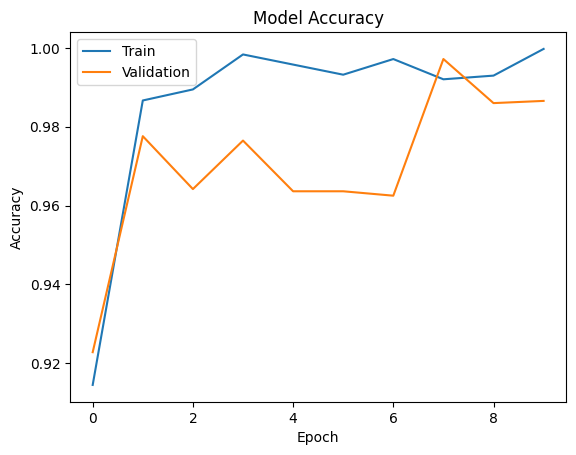

In [ ]:
# train & val_accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predictions
predictions = model.predict(test_data)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data.classes

class_names = list(test_data.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(true_classes, predicted_classes,
                            target_names=class_names))

print("\nConfusion Matrix:\n")
print(confusion_matrix(true_classes, predicted_classes))

56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 390ms/step

Classification Report:

               precision    recall  f1-score   support

    Apple Red       0.26      0.27      0.26       500
       Banana       0.19      0.19      0.19       327
Citrus Orange       0.19      0.19      0.19       278
        Mango       0.17      0.15      0.16       289
   Strawberry       0.26      0.26      0.26       393

     accuracy                           0.22      1787
    macro avg       0.21      0.21      0.21      1787
 weighted avg       0.22      0.22      0.22      1787


Confusion Matrix:

[[134 106  79  73 108]
 [111  62  49  52  53]
 [ 89  40  52  43  54]
 [ 78  53  38  44  76]
 [112  66  60  54 101]]
